# Data

> Core data structures and classes for biomedical imaging, integrating MONAI's MetaTensors with fastai's transform pipelines.

The `bioMONAI.data.core` module introduces specialized base classes (`BioDataClass`, `BioImageBase`, etc.) to represent various bioimaging data structures. By addressing metaclass conflicts and providing built-in visualization utilities, these classes facilitate the seamless integration of complex multidimensional medical images into standard machine learning workflows.

In [ ]:
#| default_exp data.core

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
from plum import dispatch



# =================================
# fastai
# =================================
from fastai.torch_core import TensorImage, TensorCategory, TensorMultiCategory
from fastai.vision.all import TransformBlock, Categorize

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.io import image_reader, image_reader_dict
from bioMONAI.visualize import show_biodata, show_multichannel

# =================================
# fasttransform patch
# =================================
import fasttransform

_original_repr = fasttransform.transform.Transform.__repr__

def _safe_repr(self):
    try:
        return _original_repr(self)
    except AttributeError as e:
        if "'_BoundFunction' object has no attribute 'methods'" in str(e):
            return f"{self.__class__.__name__}(...)"
        raise

fasttransform.transform.Transform.__repr__ = _safe_repr

## Data Types

The module introduces specialized classes to represent various bioimaging data structures, facilitating seamless integration with machine learning workflows. By addressing metaclass conflicts and providing built-in visualization utilities, these classes enable the direct use of multidimensional medical images in standard pipelines.

In [ ]:
#| export

class MetaResolver(type(torchTensor), metaclass=BypassNewMeta):
    """
    The `MetaResolver` class addresses metaclass conflicts, ensuring compatibility across different data structures. This is particularly useful when integrating with libraries that have specific metaclass requirements.
    """
    pass
    

In [ ]:
# Example: Using MetaResolver to create a custom tensor class without metaclass conflicts
from fastai.vision.all import TensorImage
import torch

class CustomBioTensor(TensorImage, metaclass=MetaResolver):
    """A custom tensor class that safely inherits from fastai's TensorImage."""
    pass

# Initialize our custom tensor
my_tensor = CustomBioTensor([1.0, 2.0, 3.0])
print(f"Type: {type(my_tensor).__name__}")
print(f"Is PyTorch Tensor? {isinstance(my_tensor, torch.Tensor)}")

Type: CustomBioTensor
Is PyTorch Tensor? True


In [ ]:
#| hide
from fastcore.test import test_eq
import torch

def test_metaresolver():
    # Test that MetaResolver allows successful class creation and tensor instantiation
    class DummyTensor(torch.Tensor, metaclass=MetaResolver):
        pass
    
    t = DummyTensor([1.0, 2.0, 3.0])
    test_eq(isinstance(t, torch.Tensor), True)
    test_eq(t.shape, torch.Size([3]))
    
    return "MetaResolver tests passed"

test_eq(test_metaresolver(), "MetaResolver tests passed")

### Base Data Classes

`BioDataClass` acts as the foundational tensor class for all bioMONAI data types. By inheriting from MONAI's `MetaTensor`, it seamlessly carries complex medical metadata (like affine matrices and spatial shapes) while behaving exactly like a standard PyTorch Tensor. It also includes built-in methods to easily hook into fastai's `DataBlock` API.

In [ ]:
#| export
class BioDataClass(MetaTensor):
    """
    Base class for bioMONAI data.
    """

    _transforms = None
    _keys = []

    # --------------------------------------------------
    # BASIC CONSTRUCTORS
    # --------------------------------------------------
    @classmethod
    def from_tensor(cls, x: torchTensor, meta: dict | None = None):
        return cls(x=x, meta=meta or {})
    
    @classmethod
    def from_metatensor(cls, x: MetaTensor):
        return cls(x=x.data, meta=x.meta)
    
    # --------------------------------------------------
    # TRANSFORMS
    # --------------------------------------------------
    @classmethod
    def set_transforms(cls, transforms):
        cls._transforms = transforms
    
    
    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        raise NotImplementedError("Subclasses must implement the `create` method to define how to instantiate from raw data.")
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        raise NotImplementedError("Subclasses must implement the `create` method to define how to instantiate from raw data.")
    
    # --------------------------------------------------
    # CREATE DATABLOCK (fastai integration)
    # --------------------------------------------------
    @classmethod
    def get_datablock(cls):
        return TransformBlock(type_tfms=[cls.from_source])

    # --------------------------------------------------
    # REPR
    # --------------------------------------------------
    def __repr__(self) -> str:
        return f"{self.__class__.__name__}{self.as_tensor().__repr__()[6:]}"

In [ ]:
# Example: Creating a BioDataClass from standard tensors and MetaTensors
import torch
from monai.data import MetaTensor

# 1. Initialize directly from a standard PyTorch Tensor with custom metadata
base_tensor = torch.tensor([1.0, 2.0, 3.0])
bio_data = BioDataClass.from_tensor(base_tensor, meta={"patient_id": "12345"})
print(f"BioDataClass shape: {bio_data.shape} | Metadata: {bio_data.meta}")

# 2. Convert an existing MONAI MetaTensor into a BioDataClass
mt = MetaTensor(x=[4, 5, 6], meta={"space": "RAS"})
bio_from_mt = BioDataClass.from_metatensor(mt)
print(f"Converted from MetaTensor: {repr(bio_from_mt)}")

BioDataClass shape: torch.Size([3]) | Metadata: {'patient_id': '12345', affine: tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]], dtype=torch.float64), space: RAS}
Converted from MetaTensor: BioDataClass([4, 5, 6])


In [ ]:
#| hide
from fastcore.test import test_eq
import torch
from monai.data import MetaTensor

def test_biodataclass():
    # Test as_subclass casting
    t_sub = torch.tensor([1, 2, 3]).as_subclass(BioDataClass)
    test_eq(isinstance(t_sub, BioDataClass), True)
    
    # Test from_metatensor metadata preservation
    mt = MetaTensor(x=[1, 2, 3], meta={"a": 1})
    bdc_mt = BioDataClass.from_metatensor(mt)
    test_eq(bdc_mt.meta["a"], 1)
    
    # Test internal representations and empty initialization
    empty_bdc = BioDataClass([])
    test_eq(empty_bdc.as_tensor().shape, torch.Size([0]))
    
    # Test custom __repr__ formatting
    repr_str = BioDataClass([1, 2, 3]).__repr__()
    test_eq(repr_str.startswith("BioDataClass"), True)

    return "BioDataClass tests passed"

test_eq(test_biodataclass(), "BioDataClass tests passed")

### Images

**`BioImageBase`** acts as the core base class for biomedical images within bioMONAI. It combines the functionality of PyTorch tensors, MONAI's `MetaTensor`, and fastai's visualization utilities (`TensorImage`).

It can be used for seamlessly loading multidimensional image data directly from raw file paths or dictionaries, manipulating image metadata, extracting Regions of Interest (ROI) via index dictionaries, and visually rendering both 2D slices and 3D volumetric grids in Jupyter notebooks.

> **Note:** Internal pure loaders (`get_loader`, `get_dict_loader`) return standard MONAI `MetaTensor` objects for maximum compatibility. High-level methods like `from_source` and `from_dict` wrap these outputs directly into `BioImageBase` instances so you can immediately use fastai's `.show()` method.

In [ ]:
#| export
class BioImageBase(BioDataClass, TensorImage, metaclass=MetaResolver):
    """
    Base class for bioimaging data.

    Provides:
    - MetaTensor integration
    - visualization utilities
    - lightweight tensor wrapper

    """

    _bypass_type = torchTensor
    _show_args = {"cmap": "gray"}
    _channels = "CZYX"
    _output = 'metatensor'
    _transforms = None
    _keys = ['image']

    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        metatensor = cls.get_loader(**kwargs)(x)
        return cls(metatensor.data, meta=metatensor.meta)
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        if keys is None:
            keys = []

        metatensor_dict = cls.get_dict_loader(keys=keys, **kwargs)(x)

        if isinstance(keys, str):
            keys = [keys]

        for key in keys:
            if key in metatensor_dict:
                x = metatensor_dict[key]
                metatensor_dict[key] = cls(x.data, meta=x.meta)

        return metatensor_dict
    
    # --------------------------------------------------
    # MONAI INTEGRATION
    # --------------------------------------------------
    @classmethod
    def get_loader(cls,**kwargs) -> Callable:
        def _load(x):
            if isinstance(x, torchTensor):
                return cls.from_tensor(x)

            local_kwargs = dict(kwargs)
            local_kwargs.setdefault("output", cls._output)
            local_kwargs.setdefault("channels", cls._channels)
            local_kwargs.setdefault("transforms", cls._transforms)

            return image_reader(
                x,
                **local_kwargs,
            )

        return _load

    @classmethod
    def get_dict_loader(cls, **kwargs) -> Callable:
        def _load_dict(data: dict):

            local_kwargs = dict(kwargs)
            local_kwargs.setdefault("keys", cls._keys)
            local_kwargs.setdefault("output", cls._output)
            local_kwargs.setdefault("channels", cls._channels)
            local_kwargs.setdefault("transforms", cls._transforms)

            return image_reader_dict(
                data,
                **local_kwargs,
            )

        return _load_dict
    
    # --------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------
    def show(self, ctx=None, figsize=None, title=None, **kwargs):
        return show_biodata(
            self,
            ctx=ctx,
            title=title if title is not None else None,
            volume_mode='grid',
            figsize=figsize,
            **merge(self._show_args, kwargs),
        )
    

--- Full Volume ---
Shape: torch.Size([1, 96, 512, 512]) | Type: BioImageBase
Original Channels format: CZYX

--- 2D ROI ---
Shape: torch.Size([1, 300, 512])

--- 3D Volumetric ROI (Grid View) ---
Shape: torch.Size([10, 300, 512])


array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

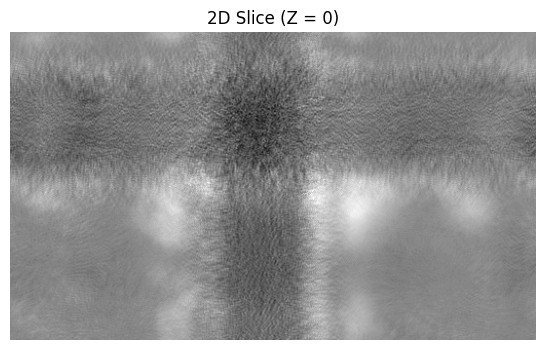

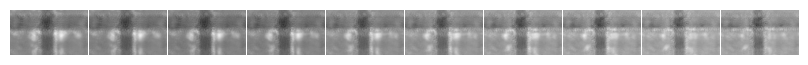

In [ ]:
# Examples: Working with BioImageBase
import warnings

image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # 1. Load an entire volume and inspect it
    print("--- Full Volume ---")
    img_full = BioImageBase.from_source(image_path)
    print(f"Shape: {img_full.shape} | Type: {type(img_full).__name__}")
    print(f"Original Channels format: {img_full.meta.get('layout')}")

    # 2. Load a 2D Region of Interest (ROI) and display it
    print("\n--- 2D ROI ---")
    roi_2d = BioImageBase.from_source(
        image_path, 
        channels="CYX", 
        ind_dict={'Z': 0, 'Y': slice(0, 300)} # First Z-slice, cropped Y
    )
    print(f"Shape: {roi_2d.shape}")

    # 3. Load a 3D ROI and display it as a grid
    print("\n--- 3D Volumetric ROI (Grid View) ---")
    roi_3d = BioImageBase.from_source(
        image_path, 
        channels="ZYX", 
        ind_dict={'Z': range(10), 'Y': slice(0, 300)} # First 10 Z-slices, cropped Y
    )
    print(f"Shape: {roi_3d.shape}")

# Show the images
roi_2d.show(title="2D Slice (Z = 0)")
roi_3d.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_bioimagebase():
    dict_path = {'image': './data_examples/example_tiff.tiff'}
    source_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Test __repr__ fallback
        repr_str = BioImageBase([1, 2, 3]).__repr__()
        test_eq(repr_str.startswith("BioImageBase"), True)
        
        # Test Dictionary Loader
        a_dict = BioImageBase.from_dict(dict_path.copy(), keys='image', channels="YX")
        test_eq(type(a_dict), dict)
        test_eq(type(a_dict['image']), BioImageBase)
        
        # Test Source Loader
        a_src = BioImageBase.from_source(source_path, channels="YX")
        test_eq(a_src.shape, a_src.meta['size_output'])
        test_eq(a_dict['image'].meta.keys(), a_src.meta.keys())
        
        # Test Pure MetaTensor Loaders
        mt_src = BioImageBase.get_loader()(source_path)
        test_eq(type(mt_src).__name__, "MetaTensor")
        
        mt_dict = BioImageBase.get_dict_loader(keys=['image'])(dict_path.copy())
        test_eq(type(mt_dict['image']).__name__, "MetaTensor")

    return "BioImageBase tests passed"

test_eq(test_bioimagebase(), "BioImageBase tests passed")

### BioImage

**`BioImage`** is a specialization of `BioImageBase` specifically tailored for standard 2D and 3D biomedical images. It directly inherits from the base class but sets the default channel layout to `"CYX"` (Channels, Y, X). This automatically handles the squeezing of unnecessary dimensions and sets the stage for standard 2D/3D transformations.

In [ ]:
#| export
class BioImage(BioImageBase):
    """
    Tensor-backed bioimage loaded from disk.
    """

    _channels = "CYX"


Type: BioImage
Shape: torch.Size([1, 300, 512])


<Axes: title={'center': 'BioImage: Z = 0'}>

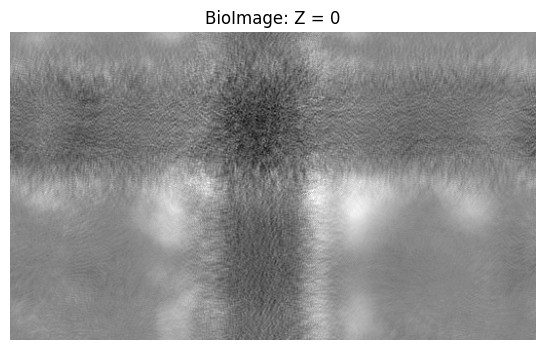

In [ ]:
# Example: Using BioImage to load a 2D Region of Interest
import warnings

image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load a 2D Region of Interest (ROI) directly as a BioImage
    image_2d = BioImage.from_source(
        image_path, 
        ind_dict={'Z': 0, 'Y': slice(0, 300)} 
    )
    print(f"Type: {type(image_2d).__name__}")
    print(f"Shape: {image_2d.shape}")

# Display the 2D image
image_2d.show(title="BioImage: Z = 0")

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_bioimage():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Test from_source loading
        img_2d = BioImage.from_source(image_path, ind_dict={'Z': 0, 'Y': slice(0, 300)})
        test_eq(type(img_2d), BioImage)
        test_eq(img_2d.shape, (1, 300, 512))
        
        # 2. Test pure loader returns MetaTensor
        img_2d_pure = BioImage.get_loader(ind_dict={'Z': 0, 'Y': slice(0, 300)})(image_path)
        test_eq(type(img_2d_pure).__name__, "MetaTensor")
        test_eq(img_2d_pure.shape, (1, 300, 512))

    return "BioImage tests passed"

test_eq(test_bioimage(), "BioImage tests passed")

### BioVolume

**`BioVolume`** is another specialization of `BioImageBase`, designed specifically for handling 3D volumetric images. By defaulting to the `"CZYX"` channel layout (Channels, Depth/Z, Height/Y, Width/X), it ensures that volumetric data is parsed with the correct spatial dimensions, making it immediately ready for 3D spatial transforms and multi-slice grid visualizations.

In [ ]:
#| export
class BioVolume(BioImageBase):
    """
    Tensor-backed volume loaded from disk.

    """

    _channels="CZYX"


Type: BioVolume
Shape: torch.Size([1, 10, 300, 512])


<Axes: >

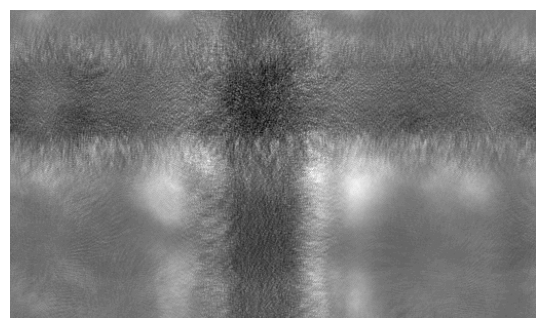

In [ ]:
# Example: Using BioVolume to load a 3D Region of Interest
import warnings

image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load a 3D Region of Interest (ROI) (e.g., the first 10 Z-slices, cropped Y)
    volume_3d = BioVolume.from_source(
        image_path, 
        ind_dict={'Z': range(10), 'Y': slice(0, 300)} 
    )
    print(f"Type: {type(volume_3d).__name__}")
    print(f"Shape: {volume_3d.shape}")

# Display the 3D volume as a grid of 2D slices
volume_3d.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_biovolume():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load from source
        vol_3d = BioVolume.from_source(image_path, ind_dict={'Z': range(10), 'Y': slice(0, 300)})
        test_eq(type(vol_3d), BioVolume)
        test_eq(vol_3d.shape, (1, 10, 300, 512))
        
        # Pure loader
        vol_3d_pure = BioVolume.get_loader(ind_dict={'Z': range(10), 'Y': slice(0, 300)}, channels="ZYX")(image_path)
        test_eq(type(vol_3d_pure).__name__, "MetaTensor")
        test_eq(vol_3d_pure.shape, (10, 300, 512))

    return "BioVolume tests passed"

test_eq(test_biovolume(), "BioVolume tests passed")

In [ ]:
#| export
def _mip_transform(cls, img, layout):
    z_dim = layout.index("Z")

    mip = torchmax(img.as_tensor(), dim=z_dim).values

    meta = dict(img.meta)
    meta["layout"] = layout.replace("Z", "")
    meta["size_output"] = tuple(mip.shape)

    return cls(x=mip, meta=meta)

In [ ]:
#| hide
from fastcore.test import test_eq
import torch
from monai.data import MetaTensor

def test_mip_transform():
    # Dummy BioMIP class
    class DummyMIP(MetaTensor):
        pass
    
    # 3D tensor (C, Z, Y, X) with max at Z=4
    t = torch.arange(500).reshape(1, 5, 10, 10).float()
    img_meta = MetaTensor(t, meta={"layout": "CZYX", "size_output": (1, 5, 10, 10)})
    
    # Apply MIP
    res = _mip_transform(DummyMIP, img_meta, "CZYX")
    
    # Verify Z is squashed
    test_eq(res.shape, (1, 10, 10))
    
    # Verify metadata
    test_eq(res.meta["layout"], "CYX")
    test_eq(res.meta["size_output"], (1, 10, 10))
    
    return "_mip_transform tests passed"

test_eq(test_mip_transform(), "_mip_transform tests passed")

### Maximum Intensity Projection (MIP)

**`BioMIP`** represents a 3D image volume as a 2D image using Maximum Intensity Projection. It automatically squashes the Z-axis (depth) by taking the maximum voxel value along that dimension. This is particularly useful for visualizing thick volumetric data (like fluorescent microscopy Z-stacks) in a flat, 2D format for quick assessments and presentations.

In [ ]:
#| export
class BioMIP(BioImageBase):
    """
    The `BioMIP` class represents a 3D image stack as a 2D image using maximum intensity projection. This is particularly useful for visualizing volumetric data in a 2D format, aiding in quick assessments and presentations.
    """
    
    _show_args = {"cmap": "gray"}
    _channels = "CZYX"
    _channel_modes = {1: "L", 3: "RGB", 4: "RGBA"}

    @classmethod
    def _get_layout(cls, img, kwargs):
        return img.meta.get("layout") or kwargs.get("channels") or cls._channels

    @classmethod
    def from_source(cls, x, keys=None, **kwargs):
        kwargs.setdefault("channels", cls._channels)

        is_dict_input = isinstance(x, dict) or (
            isinstance(x, Sequence)
            and x
            and isinstance(x[0], dict)
        )

        if is_dict_input:
            out = super(cls, cls).from_source(
                x,
                keys=keys,
                **kwargs,
            )

            if keys is None:
                keys = []

            if isinstance(keys, str):
                keys = [keys]

            layout = kwargs.get("channels")

            for key in keys:
                img = out[key]
                out[key] = _mip_transform(cls, img, layout)

            return out

        img = super(cls, cls).from_source(x, **kwargs)

        layout = kwargs.get("channels")

        return _mip_transform(cls, img, layout)


Type: BioMIP
Projected Shape: torch.Size([1, 512, 512])
Final Layout: CYX


<Axes: title={'center': 'Maximum Intensity Projection'}>

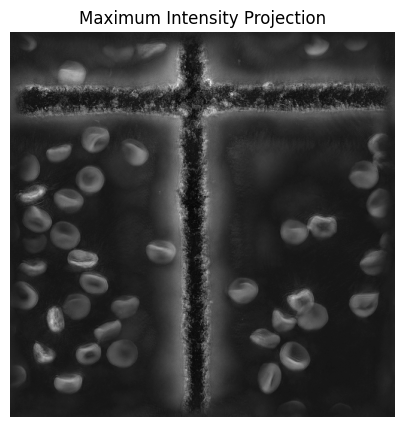

In [ ]:
# Example: Generating a Maximum Intensity Projection from a 3D volume
import warnings

image_path = './data_examples/example_tiff.tiff'

# Silence the harmless TIFF 'ResolutionUnit' warning to keep the console clean.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load the volume and automatically project it to 2D
    image_mip = BioMIP.from_source(image_path)
    print(f"Type: {type(image_mip).__name__}")
    print(f"Projected Shape: {image_mip.shape}")
    print(f"Final Layout: {image_mip.meta.get('layout')}")

# Display the resulting 2D projection
image_mip.show(title="Maximum Intensity Projection", figsize=(5, 5))

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_biomip():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load MIP (original: 1x96x512x512)
        img_mip = BioMIP.from_source(image_path)
        
        # Verify Z is squashed
        test_eq(type(img_mip), BioMIP)
        test_eq(img_mip.shape, (1, 512, 512))
        test_eq(img_mip.meta['layout'], "CYX")

    return "BioMIP tests passed"

test_eq(test_biomip(), "BioMIP tests passed")

### BioVideo

**`BioVideo`** is a specialization of `BioImageBase` designed for temporal or video data. By setting the default channel layout to `"CTYX"` (Channels, Time/Frames, Height/Y, Width/X), it ensures that time-series images (like live-cell imaging or standard video files) are parsed correctly for spatiotemporal transforms and frame-by-frame visualization.

In [ ]:
#| export
class BioVideo(BioImageBase):
    """
    Tensor-backed video loaded from disk.

    This is the class that:
    - uses image_reader
    - handles transforms
    - returns MetaTensor-backed images
    """

    _channels="CTYX"
    

In [ ]:
# Example: Loading temporal/video data using BioVideo
import warnings

image_path = './data_examples/example_tiff.tiff'

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load data as a temporal sequence
    video_seq = BioVideo.from_source(image_path)
    print(f"Type:   {type(video_seq).__name__}")
    print(f"Shape:  {video_seq.shape}")
    print(f"Layout: {video_seq.meta.get('layout')}")

Type:   BioVideo
Shape:  torch.Size([1, 1, 512, 512])
Layout: CTYX


In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_biovideo():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load
        vid = BioVideo.from_source(image_path)
        
        # Verify
        test_eq(type(vid), BioVideo)
        test_eq(vid.meta['layout'], "CTYX")
        test_eq(vid.ndim, 4)

    return "BioVideo tests passed"

test_eq(test_biovideo(), "BioVideo tests passed")

### BioMultiChannel

**`BioMultiChannel`** is a specialized class designed for handling multi-channel 2D and 3D images, assuming a `"CZYX"` layout by default. 

A key feature of this class is its ability to automatically merge the Channel (C) and Depth (Z) dimensions (`merge_cd=True`). This is particularly useful in microscopy, where multi-channel 3D stacks are often flattened or interleaved into a single sequential axis to simplify downstream visualization (`show()`) and processing.

In [ ]:
#| export
class BioMultiChannel(BioImageBase):
    """
    Multi-channel 2D/3D image assuming CZYX layout.
    """

    @classmethod
    def _apply_mip(cls, tensor, merge_cd, interleaved, **kwargs):
            layout = (
                kwargs.get("layout")
                or getattr(tensor, "meta", {}).get("layout")
                or cls._channels
            )

            if not merge_cd:
                if hasattr(tensor, "meta"):
                    tensor.meta["layout"] = layout
                    tensor.meta["size_output"] = tuple(tensor.shape)
                return tensor

            if layout is None or "C" not in layout or "Z" not in layout:
                raise ValueError(
                    f"BioMultiChannel merge_cd requires C and Z axes, got {layout!r}"
                )

            c_dim = layout.index("C")
            z_dim = layout.index("Z")

            c = tensor.shape[c_dim]
            d = tensor.shape[z_dim]

            spatial_dims = [i for i in range(tensor.ndim) if i not in (c_dim, z_dim)]

            if interleaved:
                permute_dims = [z_dim, c_dim, *spatial_dims]
            else:
                permute_dims = [c_dim, z_dim, *spatial_dims]

            tensor = tensor.permute(*permute_dims)
            tensor = tensor.reshape(c * d, *tensor.shape[2:])

            output_layout = layout.replace("Z", "")

            if hasattr(tensor, "meta"):
                tensor.meta["layout"] = output_layout
                tensor.meta["size_output"] = tuple(tensor.shape)

            return tensor
    
    @classmethod
    def from_source(
        cls,
        x: PathLike | Sequence[PathLike] | torchTensor,
        keys=None,
        merge_cd: bool = True,
        interleaved: bool = True,
        **kwargs,
    ):
        kwargs.setdefault("channels", cls._channels)

        out = super().from_source(x, keys=keys, **kwargs)

        if isinstance(out, dict):
            return {k: cls._apply_mip(v, merge_cd=merge_cd, interleaved=interleaved, **kwargs) for k, v in out.items()}

        return cls._apply_mip(out, merge_cd=merge_cd, interleaved=interleaved, **kwargs)

    def show(self, ctx=None, **kwargs):
        return show_multichannel(self, ctx=ctx, **merge(self._show_args, kwargs))



Type:   BioMultiChannel
Shape:  torch.Size([96, 512, 512])
Layout: CYX


<Axes: >

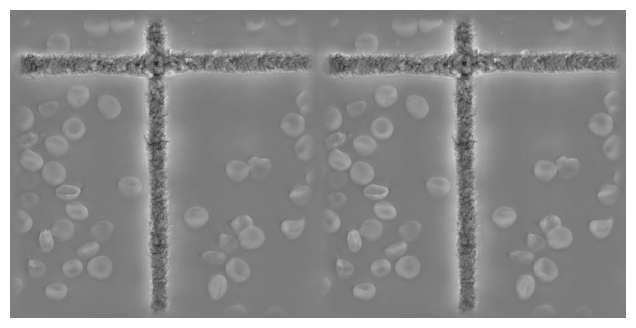

In [ ]:
# Example: Loading and flattening a multi-channel 3D stack
import warnings

image_path = './data_examples/example_tiff.tiff'

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    # Load the image, automatically merging Channels and Z-depth
    image_mlt = BioMultiChannel.from_source(image_path)
    
    print(f"Type:   {type(image_mlt).__name__}")
    print(f"Shape:  {image_mlt.shape}")
    print(f"Layout: {image_mlt.meta.get('layout')}")

# Display the multi-channel sequence
image_mlt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_biomultichannel():
    image_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load
        img_mlt = BioMultiChannel.from_source(image_path)
        
        # Verify shape (C=1, Z=96 -> merged C=96)
        test_eq(type(img_mlt), BioMultiChannel)
        test_eq(tuple(img_mlt.shape), (96, 512, 512))
        test_eq(img_mlt.meta['layout'], "CYX")

    return "BioMultiChannel tests passed"

test_eq(test_biomultichannel(), "BioMultiChannel tests passed")

### Categorical Labels

**`BioLabel`** is a specialized data class for handling categorical data, such as classification targets. Built on top of fastai's `Categorize` transform, it automatically manages vocabulary creation, handles sorting, and seamlessly maps textual labels to integer IDs (and vice versa). It fully supports both standard and dictionary-based data pipelines.

In [ ]:
#| export
class BioLabel(BioDataClass):
    """
    Data class for Categorical data.

    """

    _keys = ['label']
    _vocab = None
    _sort = True
    _add_na = False

    # --------------------------------------------------
    # LOADING
    # --------------------------------------------------
    @classmethod
    def from_source(cls, x, **kwargs):
        cat = cls.get_label(**kwargs)
        return cat(x)
    
    @classmethod
    def from_dict(cls, x:dict, keys:str|Iterable[str]=None, **kwargs):
        cat = cls.get_dict_label(keys=keys, **kwargs)
        return cat(x)
    
    # --------------------------------------------------
    # MONAI INTEGRATION
    # --------------------------------------------------
    @classmethod
    def get_label(cls,**kwargs) -> Callable:

        vocab = kwargs.get('vocab', cls._vocab)
        sort = kwargs.get('sort', cls._sort)
        add_na = kwargs.get('add_na', cls._add_na)

        cat = Categorize(vocab=vocab, sort=sort, add_na=add_na)

        return cat

    @classmethod
    def get_dict_label(cls, **kwargs) -> Callable:

        vocab = kwargs.get('vocab', cls._vocab)
        sort = kwargs.get('sort', cls._sort)
        add_na = kwargs.get('add_na', cls._add_na)
        keys = kwargs.get("keys", cls._keys)

        if isinstance(keys, str):
            keys = [keys]

        cat = Categorize(vocab=vocab, sort=sort, add_na=add_na)

        def _load_dict(data: dict):
            out = data.copy()
            for key in keys:
                out[key] = cat(data[key])
            return out

        # attach attrs
        _load_dict.vocab = vocab
        _load_dict.sort = sort
        _load_dict.add_na = add_na
        _load_dict.keys = keys
        _load_dict.cat = cat

        return _load_dict

    
    

In [ ]:
# Example: Encoding and decoding categorical labels using BioLabel
from fastai.data.transforms import Categorize

# 1. Initialize the label encoder with a specific vocabulary
# (Note: duplicates are removed and the vocabulary is sorted by default)
label_encoder = BioLabel.get_label(vocab=['malignant', 'benign', 'benign', 'normal'])

print(f"Generated Vocabulary: {list(label_encoder.vocab)}")

# 2. Encode a string label into an integer ID
encoded_id = label_encoder('malignant')
print(f"Encoded ID for 'malignant': {encoded_id}")

# 3. Decode the integer ID back to the original string
decoded_label = label_encoder.decode(encoded_id)
print(f"Decoded Label for ID {encoded_id}: {decoded_label}")

Generated Vocabulary: ['benign', 'malignant', 'normal']
Encoded ID for 'malignant': TensorCategory(1)
Decoded Label for ID TensorCategory(1): malignant


In [ ]:
#| hide
from fastcore.test import test_eq

def test_biolabel():
    # Setup
    t = BioLabel.get_label(vocab=['b', 'a', 'a', 'a', 'c'])
    
    # Check vocab sorting and uniqueness
    test_eq(list(t.vocab), ['a', 'b', 'c'])
    
    # Check decoding
    test_eq(t.decode(1), 'b')
    
    # Check encoding
    test_eq(t('b'), 1)
    
    # Verify method absence
    test_eq(hasattr(BioLabel, "get_loader"), False)
    
    # Check dict loader
    dict_loader = BioLabel.get_dict_label(keys=['label'], vocab=['a', 'b'])
    res = dict_loader({'label': 'a', 'other': 'keep'})
    test_eq(res['label'], 0)
    test_eq(res['other'], 'keep')

    return "BioLabel tests passed"

test_eq(test_biolabel(), "BioLabel tests passed")

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()